In [1]:
from ecnet.datasets import load_bp
from ecnet.datasets import QSPRDataset
from sklearn.model_selection import train_test_split

smiles, targets = load_bp()

smiles_train, smiles_test, targets_train, targets_test = train_test_split(smiles, targets, test_size=0.2, random_state=24)

dataset_train = QSPRDataset(smiles_train, targets_train, backend='alvadesc')
dataset_test = QSPRDataset(smiles_test, targets_test, backend='alvadesc')

In [2]:
from ecnet.tasks import select_rfr

desc_idx, desc_imp = select_rfr(dataset_train, total_importance=0.999, n_estimators=100, n_jobs=4)
dataset_train.set_desc_index(desc_idx)
dataset_test.set_desc_index(desc_idx)
print(dataset_train.desc_names[:5], desc_imp[:5])
print(dataset_train.desc_vals.shape, dataset_test.desc_vals.shape)
with open('bp_desc.txt', 'w') as txt_file:
    txt_file.writelines([str(i) + '\n' for i in desc_idx])
txt_file.close()

['GMTIV', 'SpAD_B(s)', 'SpAbs_B(s)', 'ATS1s', 'ATSC1e'] [0.29116008566180746, 0.12284900171677089, 0.03943470601799848, 0.03271393304300713, 0.026464863698300402]
torch.Size([164, 1148]) torch.Size([41, 1148])


In [3]:
from ecnet import ECNet

net = ECNet(dataset_train.desc_vals.shape[1], dataset_train.target_vals.shape[1], 128, 1)
loss_train, loss_valid = net.fit(
    dataset=dataset_train,
    batch_size=8,
    epochs=1024,
    valid_size=0.2,
    shuffle=True,
    lr=0.0005,
    patience=64,
    verbose=10
)

Epoch: 0 | Train loss: 15447.219984680642 | Valid loss: 9223372036854775807
Epoch: 10 | Train loss: 1358.8665939214575 | Valid loss: 1684.8074951171875
Epoch: 20 | Train loss: 533.5922702468988 | Valid loss: 1317.5902099609375
Epoch: 30 | Train loss: 800.959512259214 | Valid loss: 1104.9984130859375
Epoch: 40 | Train loss: 994.9438695543595 | Valid loss: 1204.4312744140625
Epoch: 50 | Train loss: 639.7712586381053 | Valid loss: 872.5630493164062
Epoch: 60 | Train loss: 814.2772573223551 | Valid loss: 747.3333740234375
Epoch: 70 | Train loss: 532.4257327946087 | Valid loss: 756.1467895507812
Epoch: 80 | Train loss: 474.77066616611626 | Valid loss: 646.29931640625
Epoch: 90 | Train loss: 789.1822171975638 | Valid loss: 712.0029907226562
Epoch: 100 | Train loss: 765.5679657914256 | Valid loss: 766.3323974609375
Epoch: 110 | Train loss: 606.3049015889641 | Valid loss: 550.5006713867188
Epoch: 120 | Train loss: 447.4841611439945 | Valid loss: 996.1893920898438
Epoch: 130 | Train loss: 1025.

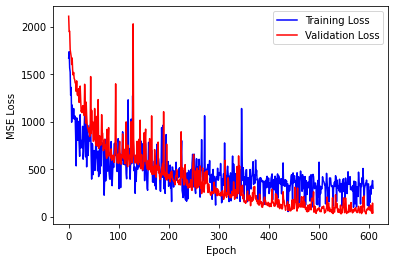

In [4]:
from matplotlib import pyplot as plt

loss_train = loss_train[5:]
loss_valid = loss_valid[5:]
epochs = [i for i in range(len(loss_train))]

plt.clf()
plt.plot(epochs, loss_train, label='Training Loss', color='blue')
plt.plot(epochs, loss_valid, label='Validation Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend(loc='upper right')
plt.show()

In [5]:
from sklearn.metrics import median_absolute_error, r2_score

results_train = net.forward(dataset_train.desc_vals).detach().numpy()
targets_train = dataset_train.target_vals.detach().numpy()
results_test = net.forward(dataset_test.desc_vals).detach().numpy()
targets_test = dataset_test.target_vals.detach().numpy()

mae_train = median_absolute_error(targets_train, results_train)
mae_test = median_absolute_error(targets_test, results_test)
r2_train = r2_score(targets_train, results_train)
r2_test = r2_score(targets_test, results_test)

print(f'Train: {mae_train} | {r2_train}')
print(f'Test: {mae_test} | {r2_test}')

Train: 2.3653717041015625 | 0.9636668404994505
Test: 4.72528076171875 | 0.9512510579526312


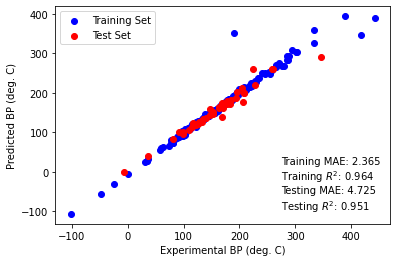

In [6]:
from matplotlib.offsetbox import AnchoredText

plt.clf()
plt.scatter(targets_train, results_train, label='Training Set', color='blue')
plt.scatter(targets_test, results_test, label='Test Set', color='red')
plt.legend(loc='upper left')
string = 'Training MAE: {:.3f}'.format(mae_train)
string += '\nTraining $R^2$: {:.3f}'.format(r2_train)
string += '\nTesting MAE: {:.3f}'.format(mae_test)
string += '\nTesting $R^2$: {:.3f}'.format(r2_test)
text_box = AnchoredText(string, frameon=True, loc=4, pad=0.5)
plt.setp(text_box.patch, facecolor='white', edgecolor='w')
plt.gca().add_artist(text_box)
plt.xlabel('Experimental BP (deg. C)')
plt.ylabel('Predicted BP (deg. C)')
plt.show()

In [7]:
net.save('bp.pt')